In [18]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style('whitegrid')

In [54]:
#Download Dataset from Kaggle
import os
from google.colab import userdata
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
!pip install kaggle
!kaggle datasets download -d mohansacharya/graduate-admissions
!unzip -o graduate-admissions.zip
!ls


Dataset URL: https://www.kaggle.com/datasets/mohansacharya/graduate-admissions
License(s): CC0-1.0
100% 9.64k/9.64k [00:00<00:00, 22.2MB/s]

Archive:  graduate-admissions.zip
  inflating: Admission_Predict.csv   
  inflating: Admission_Predict_Ver1.1.csv  
Admission_Predict.csv	  Admission_Predict_Ver1.1.csv	sample_data
admission-prediction.zip  graduate-admissions.zip


In [55]:
#Load and Inspect data
df=pd.read_csv('Admission_Predict_Ver1.1.csv')
df.columns = df.columns.str.strip()    # Clean up column names (this dataset commonly has stray spaces)

df.head()


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [57]:
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


In [58]:
df.isna().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


In [59]:
# Drop Serial No. if present — it's just a row identifier, not a useful feature
if 'Serial No.' in df.columns:
    df = df.drop(columns=['Serial No.'])

df.columns.tolist()

['GRE Score',
 'TOEFL Score',
 'University Rating',
 'SOP',
 'LOR',
 'CGPA',
 'Research',
 'Chance of Admit']

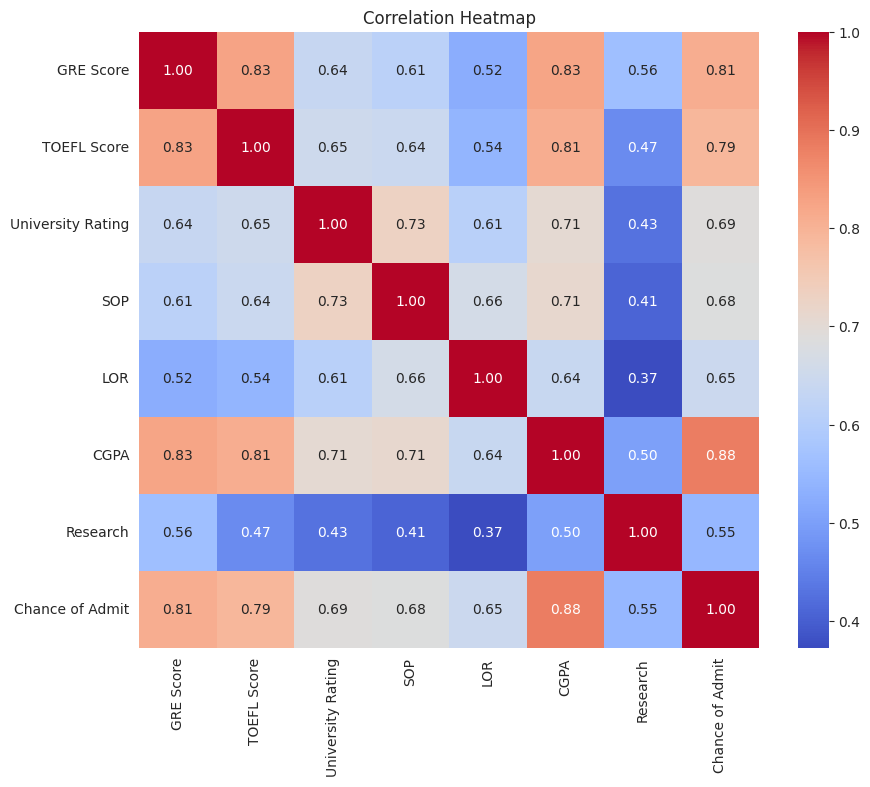

In [60]:
#Exploratory Data Analysis
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

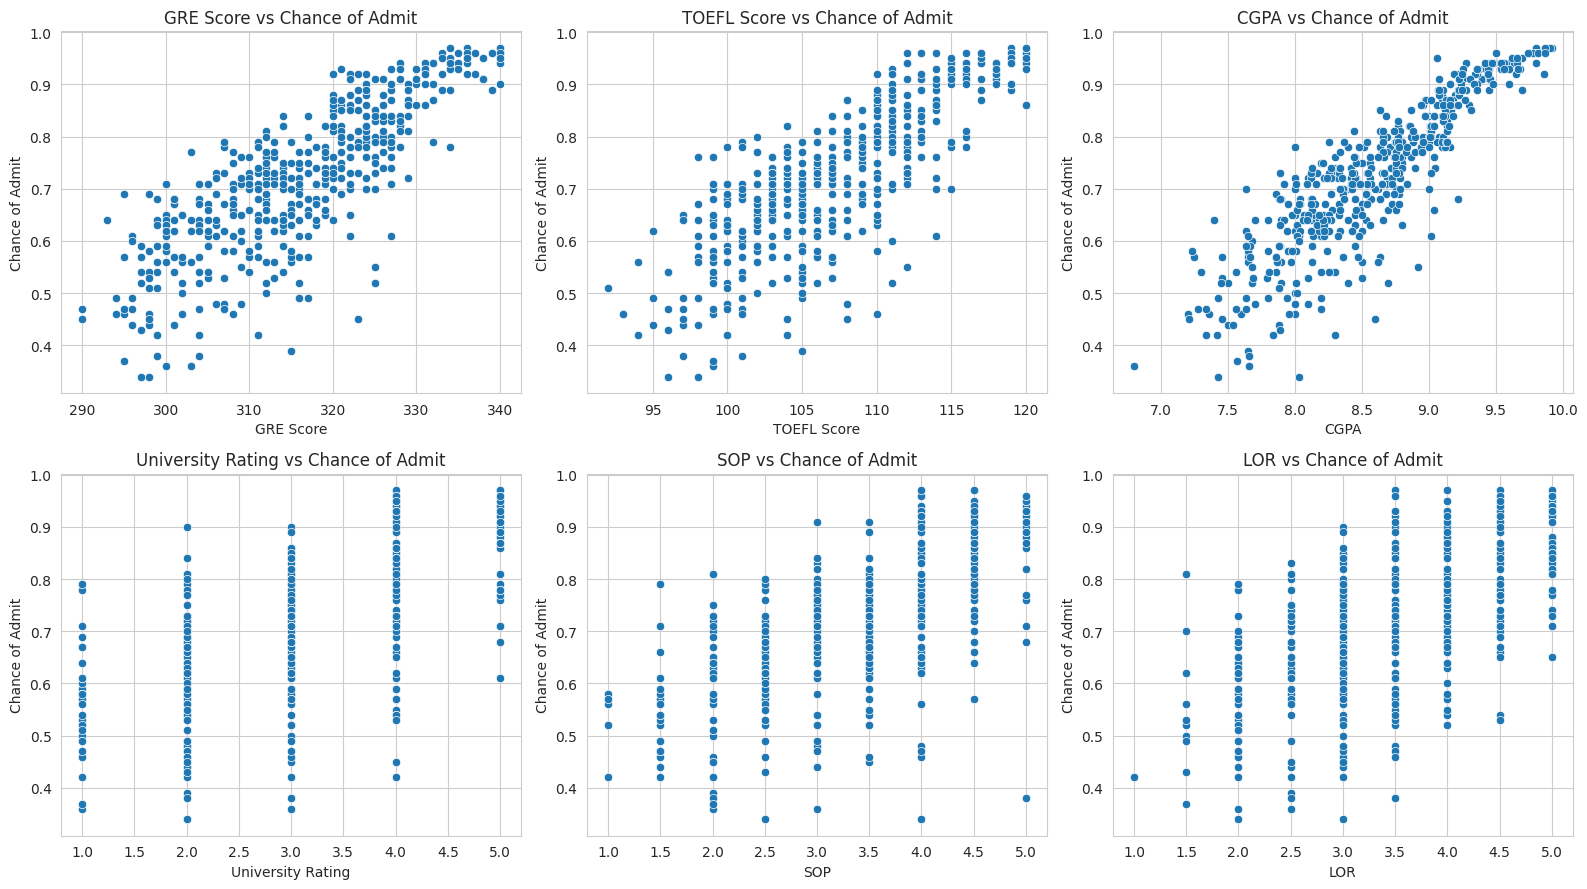

In [61]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
features_to_plot = ['GRE Score', 'TOEFL Score', 'CGPA', 'University Rating', 'SOP', 'LOR']

for ax, col in zip(axes.flatten(), features_to_plot):
    sns.scatterplot(x=col, y='Chance of Admit', data=df, ax=ax)
    ax.set_title(f'{col} vs Chance of Admit')

plt.tight_layout()
plt.show()

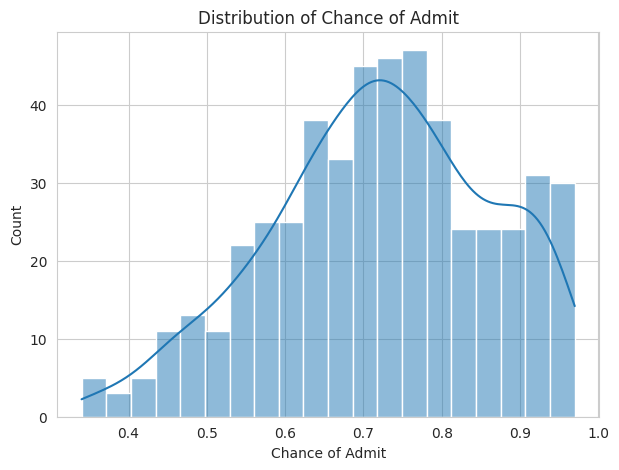

In [62]:
plt.figure(figsize=(7, 5))
sns.histplot(df['Chance of Admit'], kde=True, bins=20)
plt.title('Distribution of Chance of Admit')
plt.show()

In [63]:
# Features and Target
X = df.drop(columns=['Chance of Admit'])
y = df['Chance of Admit']

X.columns.tolist()

['GRE Score',
 'TOEFL Score',
 'University Rating',
 'SOP',
 'LOR',
 'CGPA',
 'Research']

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')

Train shape: (400, 7), Test shape: (100, 7)


In [65]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [66]:
#Train the Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print('Model trained successfully.')

Model trained successfully.


In [67]:
#Evaluate the Model
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'MAE:  {mae:.4f}')
print(f'MSE:  {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R2 Score: {r2:.4f}')

MAE:  0.0427
MSE:  0.0037
RMSE: 0.0609
R2 Score: 0.8188


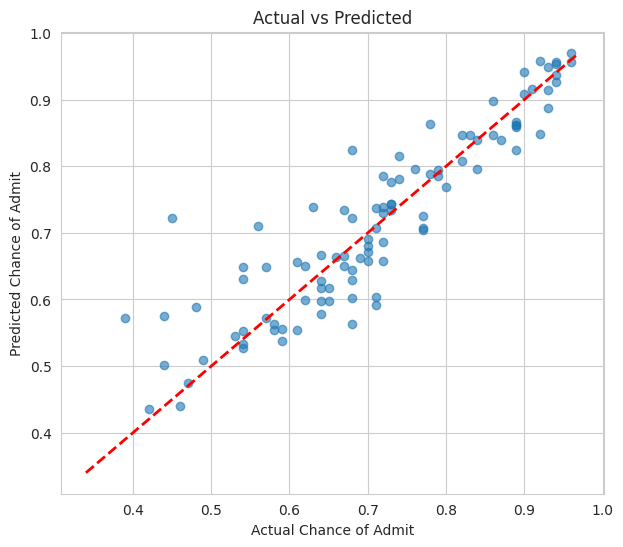

In [68]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Chance of Admit')
plt.ylabel('Predicted Chance of Admit')
plt.title('Actual vs Predicted')
plt.show()

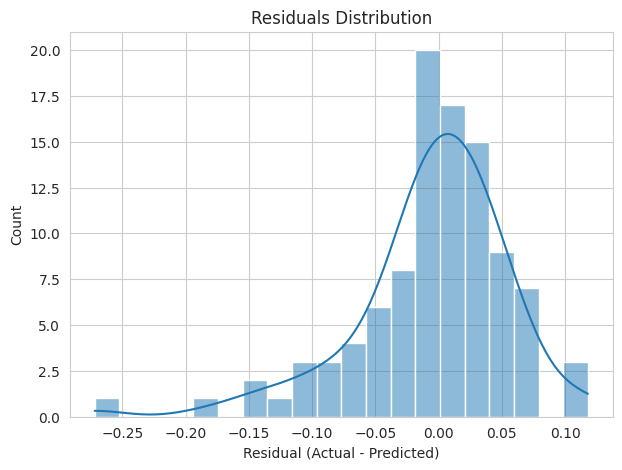

In [69]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
sns.histplot(residuals, kde=True, bins=20)
plt.title('Residuals Distribution')
plt.xlabel('Residual (Actual - Predicted)')
plt.show()

In [70]:
#Feature Importance (Coefficients)
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

coef_df

,Feature,Coefficient
5,CGPA,0.067581
0,GRE Score,0.026671
1,TOEFL Score,0.018226
4,LOR,0.015866
6,Research,0.011940
2,University Rating,0.002940
3,SOP,0.001788


/tmp/ipykernel_715/2895003878.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')


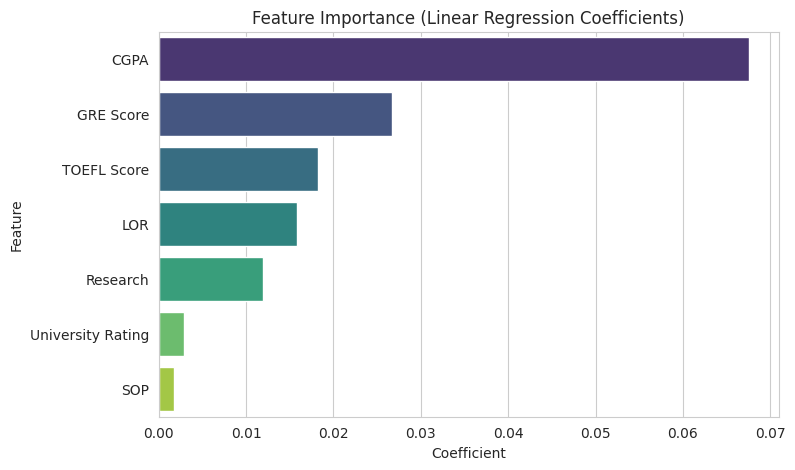

In [71]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.show()

In [73]:
#Prediction on New Data
new_applicant = pd.DataFrame([{
    'GRE Score': 320,
    'TOEFL Score': 110,
    'University Rating': 4,
    'SOP': 4.0,
    'LOR': 4.5,
    'CGPA': 9.0,
    'Research': 1
}])

new_applicant = new_applicant[X.columns]

new_applicant_scaled = scaler.transform(new_applicant)
predicted_chance = model.predict(new_applicant_scaled)

print(f'Predicted Chance of Admit: {predicted_chance[0]:.2%}')

Predicted Chance of Admit: 81.90%


Summary

- Trained a Linear Regression model to predict **Chance of Admit** from applicant features.
- Evaluated using MAE, MSE, RMSE, and R2 score.
- Reviewed feature coefficients to see which factors (e.g. CGPA, GRE Score) most influence admission chances.
- Demonstrated prediction for a new, unseen applicant.